In [1]:
import os
import re
from pypdf import PdfReader
import json
import string
import random
import pandas as pd
import numpy as np
import torch
from collections import Counter
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Import data
lstm = PdfReader(r"C:\Users\USER\Downloads\LSTM.pdf")
ailyn = PdfReader(r"C:\Users\USER\Downloads\AILYN.pdf")

text = ""

for i in lstm.pages:
    text += i.extract_text() + "\n"

for j in ailyn.pages:
    text += j.extract_text() + "\n"

In [3]:
# Clean text
def clean_text(text):
    # Standardize common PDF ligatures
    text = text.replace("ﬁ", "fi").replace("ﬀ", "ff").replace("ﬂ", "fl").replace("ﬃ", "ffi")
    
    # Remove citations like [1] or [12, 15]
    text = re.sub(r'\[\d+(?:,\s*\d+)*\]', '', text)
    
    # 3. Clean punctuation and lowercase
    clean = str.maketrans('', '', string.punctuation)
    text = text.translate(clean)
    text = text.replace("\n", " ").lower().split()
    
    return text

text = clean_text(text)
print(text)

['department', 'of', 'computer', 'science', 'tdt4173', 'assignment', '1', 'time', 'series', 'long', 'shortterm', 'memory', 'rnn', 'group', 'group', '8', 'time', 'series', 'authors', 'adrian', 'kjærran', 'adriankj', 'erling', 'stray', 'bugge', 'erlinsb', 'christian', 'bakke', 'vennerød', 'christbv', 'may', '17', '2021', 'arxiv210506756v1', 'cslg', '14', 'may', '2021', 'abstract', 'this', 'paper', 'is', 'the', 'first', 'assignment', 'in', 'the', 'course', 'machine', 'learning', 'tdt4173', 'fall', '2020', 'the', 'project', 'was', 'conducted', 'by', 'reading', 'through', 'some', 'of', 'the', 'latest', 'developments', 'within', 'timeseries', 'forecasting', 'methods', 'in', 'the', 'scientific', 'community', 'over', 'the', 'past', '5', 'years', 'the', 'result', 'is', 'a', 'summary', 'of', 'the', 'essential', 'aspects', 'in', 'this', 'paper', 'we', 'introduce', 'an', 'lstm', 'cell’s', 'architecture', 'and', 'explain', 'how', 'different', 'com', 'ponents', 'go', 'together', 'to', 'alter', 'the'

In [4]:
# Turn to and split

tokens = pd.Series(text)

split = int(0.8 * len(tokens))
train = tokens[:split]
test = tokens[split:]

In [5]:
# I need to transform train data to tokens then transform test from train
def tokenizer(train, test):
    """
    Create unique id from the train data,
    map it to the test data, and if there's
    any unique in the test, change it to 0
    """
    unique_tokens = list(dict.fromkeys(train))
    
    # IDs start from 1
    tokens_map = {word: idx + 1 for idx, word in enumerate(unique_tokens)}
    
    # Reserve 0 for unknown
    tokens_map["UKN"] = 0
    
    # Tokenize
    train_token = [tokens_map.get(tk, 0) for tk in train]
    test_token  = [tokens_map.get(tk, 0) for tk in test]
    
    return train_token, test_token, tokens_map


# Usage
train, test, word_to_id = tokenizer(train, test)

In [6]:
# Save json
with open("tokenizer.json", "w", encoding="utf-8") as f:
    json.dump(word_to_id, f, indent=4, ensure_ascii=False)

In [7]:
# create window function and transform to array

def window(tokens, input_length, output_length):

    X_train = []
    y_train = []
    for i in range(len(tokens) - input_length - output_length + 1):
        X = tokens[i:input_length+i]
        y = tokens[i+input_length:i+input_length+output_length]
        
        X_train.append(X)
        y_train.append(y)

    return np.array(X_train, dtype=np.int32), np.array(y_train, dtype=np.int32).squeeze(-1)

In [8]:
X_train, y_train = window(train, 30, 1)
X_test, y_test = window(test, 30, 1)

In [9]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (9388, 30)
y_train shape: (9388,)


In [10]:
# lets convert it to tensor dataset

X_train_tensors = torch.tensor(X_train, dtype=torch.long)
y_train_tensors = torch.tensor(y_train, dtype=torch.long)

X_test_tensors = torch.tensor(X_test, dtype=torch.long)
y_test_tensors = torch.tensor(y_test, dtype=torch.long)

In [11]:
# Save to tensor
train_tensor = TensorDataset(X_train_tensors, y_train_tensors)
test_tensor = TensorDataset(X_test_tensors, y_test_tensors)

In [12]:
# Save to data loader
train_loader = DataLoader(train_tensor, batch_size=32, shuffle=True)
test_loader = DataLoader(test_tensor, batch_size=32, shuffle=False)

In [13]:
# Model Achitecture

class WordPred(nn.Module):
    def __init__(self, vocab_size, hidden_dim=64, embed_dim=64):
        super().__init__()

        # Lets use embaddings
        self.embed = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, vocab_size),
        )

    def forward(self, X):
        emb = self.embed(X)
        _, (h_n, _) = self.lstm(emb)

        return self.fc(h_n[-1])

In [14]:
model = WordPred(len(word_to_id))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [59]:
# Training function

def train(model, criterion, optimizer, train_loader, epochs):
    model.train()
    loss_plot = []
    for epoch in range(epochs):
        total_loss=0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss+=loss.item()
            loss.backward()
            optimizer.step()
        mean_loss = total_loss/len(train_loader)
        loss_plot.append(mean_loss)
        print(f" Epoch: {epoch+1}, Loss: {mean_loss:.2f}")

    plt.figure(figsize=(7, 5))
    plt.plot(loss_plot)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.savefig("Loss plot.png")
    plt.show()

 Epoch: 1, Loss: 6.95
 Epoch: 2, Loss: 6.38
 Epoch: 3, Loss: 6.21
 Epoch: 4, Loss: 6.06
 Epoch: 5, Loss: 5.90
 Epoch: 6, Loss: 5.75
 Epoch: 7, Loss: 5.61
 Epoch: 8, Loss: 5.47
 Epoch: 9, Loss: 5.32
 Epoch: 10, Loss: 5.17
 Epoch: 11, Loss: 5.04
 Epoch: 12, Loss: 4.91
 Epoch: 13, Loss: 4.88
 Epoch: 14, Loss: 4.74
 Epoch: 15, Loss: 4.63
 Epoch: 16, Loss: 4.52
 Epoch: 17, Loss: 4.46
 Epoch: 18, Loss: 4.32
 Epoch: 19, Loss: 4.16
 Epoch: 20, Loss: 4.01
 Epoch: 21, Loss: 3.92
 Epoch: 22, Loss: 3.81
 Epoch: 23, Loss: 3.70
 Epoch: 24, Loss: 3.63
 Epoch: 25, Loss: 3.55
 Epoch: 26, Loss: 3.48
 Epoch: 27, Loss: 3.40
 Epoch: 28, Loss: 3.29
 Epoch: 29, Loss: 3.21
 Epoch: 30, Loss: 3.12
 Epoch: 31, Loss: 3.09
 Epoch: 32, Loss: 3.00
 Epoch: 33, Loss: 2.95
 Epoch: 34, Loss: 2.87
 Epoch: 35, Loss: 2.82
 Epoch: 36, Loss: 2.75
 Epoch: 37, Loss: 2.70
 Epoch: 38, Loss: 2.63
 Epoch: 39, Loss: 2.56
 Epoch: 40, Loss: 2.49
 Epoch: 41, Loss: 2.40
 Epoch: 42, Loss: 2.36
 Epoch: 43, Loss: 2.35
 Epoch: 44, Loss: 2.

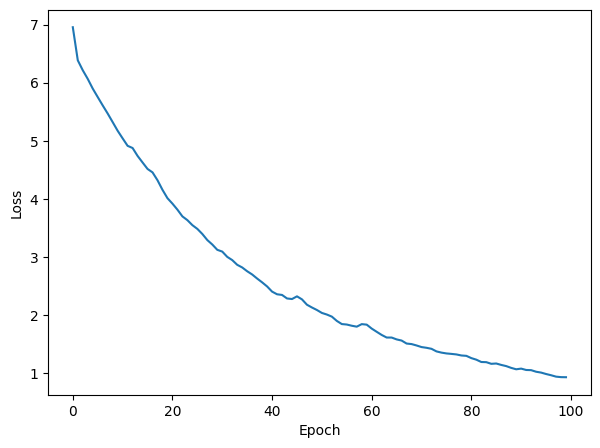

In [16]:
train(model, criterion, optimizer, train_loader, 100)

In [17]:
model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)

        preds = torch.argmax(y_pred, dim=1)

        all_predictions.append(preds)
        all_actual.append(y_batch.squeeze())

predictions = torch.cat(all_predictions)
actual = torch.cat(all_actual)

correct = (predictions == actual).sum().item()
accuracy = correct / len(actual)

print(f"Testing Accuracy: {accuracy:.2%}")

Testing Accuracy: 5.29%


In [18]:
# Train Data

model.eval()
all_predictions = []
all_actual = []

with torch.no_grad():
    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        predicted = y_pred.argmax(dim=1)
        
        all_predictions.append(predicted)
        all_actual.append(y_batch.squeeze())


predictions = torch.cat(all_predictions)
actual = torch.cat(all_actual)


correct = (predictions == actual).sum().item()
accuracy = correct / len(actual)

print(f"Training Accuracy: {accuracy:.2%}")

Training Accuracy: 85.45%


In [19]:
def make_pred(text, word_to_id, model,
              max_new_words=20,
              k=5,
              temperature=0.8):

    model.eval()

    # Convert text to tokens
    words = clean_text(text)
    tokens = [word_to_id.get(w, 0) for w in words]

    # Create id -> word dictionary
    id_to_word = {idx: word for word, idx in word_to_id.items()}

    seq_length = 30

    with torch.no_grad():
        for _ in range(max_new_words):

            # Take the last seq_length tokens
            input_tokens = tokens[-seq_length:]

            input_tensor = torch.tensor(
                [input_tokens],
                dtype=torch.long
            )

            output = model(input_tensor)

            # Apply temperature
            logits = output / temperature

            # Convert to probabilities
            probs = torch.softmax(logits, dim=1)

            # Take top-k candidates
            top_probs, top_indices = torch.topk(
                probs,
                k=min(k, probs.size(1)),
                dim=1
            )

            # Sample from top-k
            sampled_idx = torch.multinomial(
                top_probs.squeeze(0),
                1
            ).item()

            next_token_id = top_indices[
                0,
                sampled_idx
            ].item()

            # Stop if UNK
            if next_token_id == 0:
                break

            # Append prediction
            tokens.append(next_token_id)
            words.append(
                id_to_word.get(next_token_id, "UKN")
            )

    return " ".join(words)

In [20]:
text = "The idea of machine learning"

output = make_pred(text, word_to_id, model)
print(output)

the idea of machine learning models building on lstm architectures can be adapted to value even linearly for each step we suspect by that however


# Training The Model on Full Data

In [25]:
# Full data in series
tokens

0        department
1                of
2          computer
3           science
4           tdt4173
            ...    
11768            to
11769       perform
11770     different
11771         tasks
11772            15
Length: 11773, dtype: object

In [65]:
# Word level tokenization

# unique words
unique_tokens = list(dict.fromkeys(tokens))

# value assignment
word_to_id = {word: idx for idx, word in enumerate(unique_tokens, start=1)}

# Add UKN for unknown words
word_to_id["<UKN>"] = 0

# convert tokens to id
data = [word_to_id.get(idx) for idx in tokens]

In [66]:
# save new word to id as tokenizer
with open(r"C:\Users\USER\Documents\MY PORTFOLIO\Language Model with LSTM\Artifacts/tokenizer.json", "w", encoding="utf-8") as f:
    json.dump(word_to_id, f)

In [52]:
# Apply window function

X, y = window(data, 30, 1)

In [56]:
# lets convert it to tensor dataset

X_tensors = torch.tensor(X, dtype=torch.long)
y_tensors = torch.tensor(y, dtype=torch.long)

In [57]:
# Save to tensor
data_tensor = TensorDataset(X_tensors, y_tensors)

# Save to loader
data_loader = DataLoader(data_tensor, batch_size=32, shuffle=True)

In [58]:
model = WordPred(len(word_to_id))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

 Epoch: 1, Loss: 6.93
 Epoch: 2, Loss: 6.50
 Epoch: 3, Loss: 6.33
 Epoch: 4, Loss: 6.10
 Epoch: 5, Loss: 5.85
 Epoch: 6, Loss: 5.61
 Epoch: 7, Loss: 5.36
 Epoch: 8, Loss: 5.12
 Epoch: 9, Loss: 4.89
 Epoch: 10, Loss: 4.66
 Epoch: 11, Loss: 4.47
 Epoch: 12, Loss: 4.27
 Epoch: 13, Loss: 4.05
 Epoch: 14, Loss: 3.86
 Epoch: 15, Loss: 3.69
 Epoch: 16, Loss: 3.52
 Epoch: 17, Loss: 3.34
 Epoch: 18, Loss: 3.19
 Epoch: 19, Loss: 3.05
 Epoch: 20, Loss: 2.93
 Epoch: 21, Loss: 2.77
 Epoch: 22, Loss: 2.67
 Epoch: 23, Loss: 2.54
 Epoch: 24, Loss: 2.46
 Epoch: 25, Loss: 2.36
 Epoch: 26, Loss: 2.29
 Epoch: 27, Loss: 2.20
 Epoch: 28, Loss: 2.11
 Epoch: 29, Loss: 2.04
 Epoch: 30, Loss: 1.97
 Epoch: 31, Loss: 1.90
 Epoch: 32, Loss: 1.84
 Epoch: 33, Loss: 1.79
 Epoch: 34, Loss: 1.76
 Epoch: 35, Loss: 1.69
 Epoch: 36, Loss: 1.62
 Epoch: 37, Loss: 1.57
 Epoch: 38, Loss: 1.53
 Epoch: 39, Loss: 1.49
 Epoch: 40, Loss: 1.45
 Epoch: 41, Loss: 1.43
 Epoch: 42, Loss: 1.39
 Epoch: 43, Loss: 1.35
 Epoch: 44, Loss: 1.

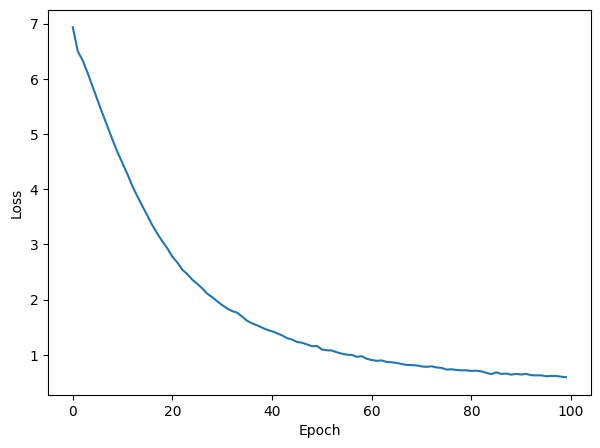

In [60]:
train(model, criterion, optimizer, data_loader, 100)

In [63]:
model.eval()

torch.save(model.state_dict(), "mini_lm.pt")

In [64]:
len(word_to_id)

2697